# Experiment 2c — Are the coupling filters robust to modelling choices?

**Reviewer question (2c):** replace visual inspection of the variant figures (S6/S7) with
**quantitative** comparison.

Three models, all fitted with the **exact main-results 6-area pop-GLM** (time-warped baseline +
trial-wise gain, coupling from all six areas, 14 stimulus conditions / 210 trials):

| model | populations | self-history |
|---|---|---|
| **main** | selected (`group_id==0`) | `refractory_additive` (f_damp) |
| **full neurons** (S6) | **all** neurons per probe (`pooling_pop(use_all=True)`) | f_damp |
| **linear self-history** (S7) | selected | **no f_damp** — linear self-coupling only |

Each is fitted for every target area and both conditions → all 36 coupling filters per model/condition
(`exp2c_variants.py`). We report the **amplitude correlation** (filter integral) and the
**delay correlation** (peak latency) across all 60 cross-area filters.

In [1]:
import os, sys, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import numpy as np, pickle, matplotlib.pyplot as plt
import GLM, utility_functions as utils
from popglm_data import Dataset, load_membership

ds = Dataset(); MEMB, CIDS = load_membership()
PROBES=['probeA','probeB','probeC','probeD','probeE','probeF']
AREA={'probeA':'AM','probeB':'PM','probeC':'V1','probeD':'LM','probeE':'AL','probeF':'RL'}
POOL_SEL={p: utils.pooling_pop(MEMB,CIDS,ds,p,0,use_all=False) for p in PROBES}   # selected
POOL_ALL={p: utils.pooling_pop(MEMB,CIDS,ds,p,0,use_all=True)  for p in PROBES}   # all neurons
print("V1 pooled mean spikes/bin:  selected = %.3f   full = %.3f  (%.2fx)"
      % (POOL_SEL['probeC'].mean(), POOL_ALL['probeC'].mean(),
         POOL_ALL['probeC'].mean()/POOL_SEL['probeC'].mean()))

V1 pooled mean spikes/bin:  selected = 0.272   full = 0.453  (1.67x)


## The three models (one fitted live for illustration)

In [2]:
CP={'peaks_max':20.2,'num':3,'nonlinear':0.5}
def fit(model, cond, target):
    pool = POOL_ALL if model=="fullpop" else POOL_SEL
    sel  = ds.running_trial_index if cond=="running" else ds.stationary_trial_index
    m = GLM.PP_GLM(dataset=ds, select_trials=sel, membership=MEMB, condition_ids=CIDS)
    m.add_effect('inhomogeneous_baseline', num=20, apply_no_penalty=True)
    for p in PROBES: m.add_effect('coupling', pool[p], apply_no_penalty=True, **CP)
    if model!="linhist":                                  # linhist = drop f_damp
        m.add_effect('refractory_additive', pool[target], tau=15, num=4, apply_no_penalty=True)
    m.add_effect('trial_coef')
    m.fit_time_warping_baseline(pool[target], verbose=False, max_iter=10, penalty=5e-1)
    return {PROBES[j]: np.asarray(m.get_filter()[1+j]) for j in range(6)}   # effects 1..6 = couplings

demo = fit("linhist", "running", "probeD")
print("live fit (linear self-history, running, target LM):  V1->LM integral = %.3f"
      % demo['probeC'].sum(), "   [main model gives 1.025]")
R = pickle.load(open("exp2c_variants.pkl","rb"))          # all 36 fits (3 models x 2 cond x 6 targets)
print("loaded %d precomputed fits" % len(R))

live fit (linear self-history, running, target LM):  V1->LM integral = 1.020    [main model gives 1.025]
loaded 36 precomputed fits


## Quantitative comparison: amplitude and delay correlation

In [3]:
def stats(mo):
    A,D=[],[]
    for co in ["running","stationary"]:
        for tg in PROBES:
            for src in PROBES:
                if src==tg: continue                      # 30 cross-area pairs per condition
                f=np.asarray(R[(mo,co,tg)][src])
                A.append(f.sum()); D.append(np.argmax(np.abs(f)))   # integral ; peak latency (ms)
    return np.array(A), np.array(D)
Am,Dm = stats("main"); Af,Df = stats("fullpop"); Al,Dl = stats("linhist")

print("%-24s %12s %12s %12s" % ("variant vs main","amplitude r","delay r","amp. scale"))
for (Av,Dv,lab) in [(Af,Df,"full neurons (S6)"), (Al,Dl,"linear self-hist (S7)")]:
    print("%-24s %12.3f %12.3f %11.2fx"
          % (lab, np.corrcoef(Am,Av)[0,1], np.corrcoef(Dm,Dv)[0,1], np.polyfit(Am,Av,1)[0]))

print("\nV1->LM coupling integral:")
print("  %-22s %9s %11s" % ("model","running","stationary"))
for mo,lab in [("main","main"),("fullpop","full neurons"),("linhist","linear self-hist")]:
    print("  %-22s %9.3f %11.3f" % (lab,
        np.asarray(R[(mo,"running","probeD")]['probeC']).sum(),
        np.asarray(R[(mo,"stationary","probeD")]['probeC']).sum()))

variant vs main           amplitude r      delay r   amp. scale
full neurons (S6)               0.874        0.756        0.50x
linear self-hist (S7)           0.924        0.837        0.96x

V1->LM coupling integral:
  model                    running  stationary
  main                       1.025       1.942
  full neurons               0.520       0.774
  linear self-hist           1.020       1.941


## V1$\to$LM example, in the layout of the supplementary grids

Each area-pair cell is split into **running (red)** and **stationary (blue)** panels, each showing just two curves: pop-GLM (solid, shaded ±2σ band) and the variant (dashed, shaded ±2σ band). For **full neurons** the variant is ~half the amplitude, so it goes on a **twin (right) axis**; for **linear self-history** the scales match, so both **share one axis**. Full 6×6 grids: `exp2c_figs.py`.

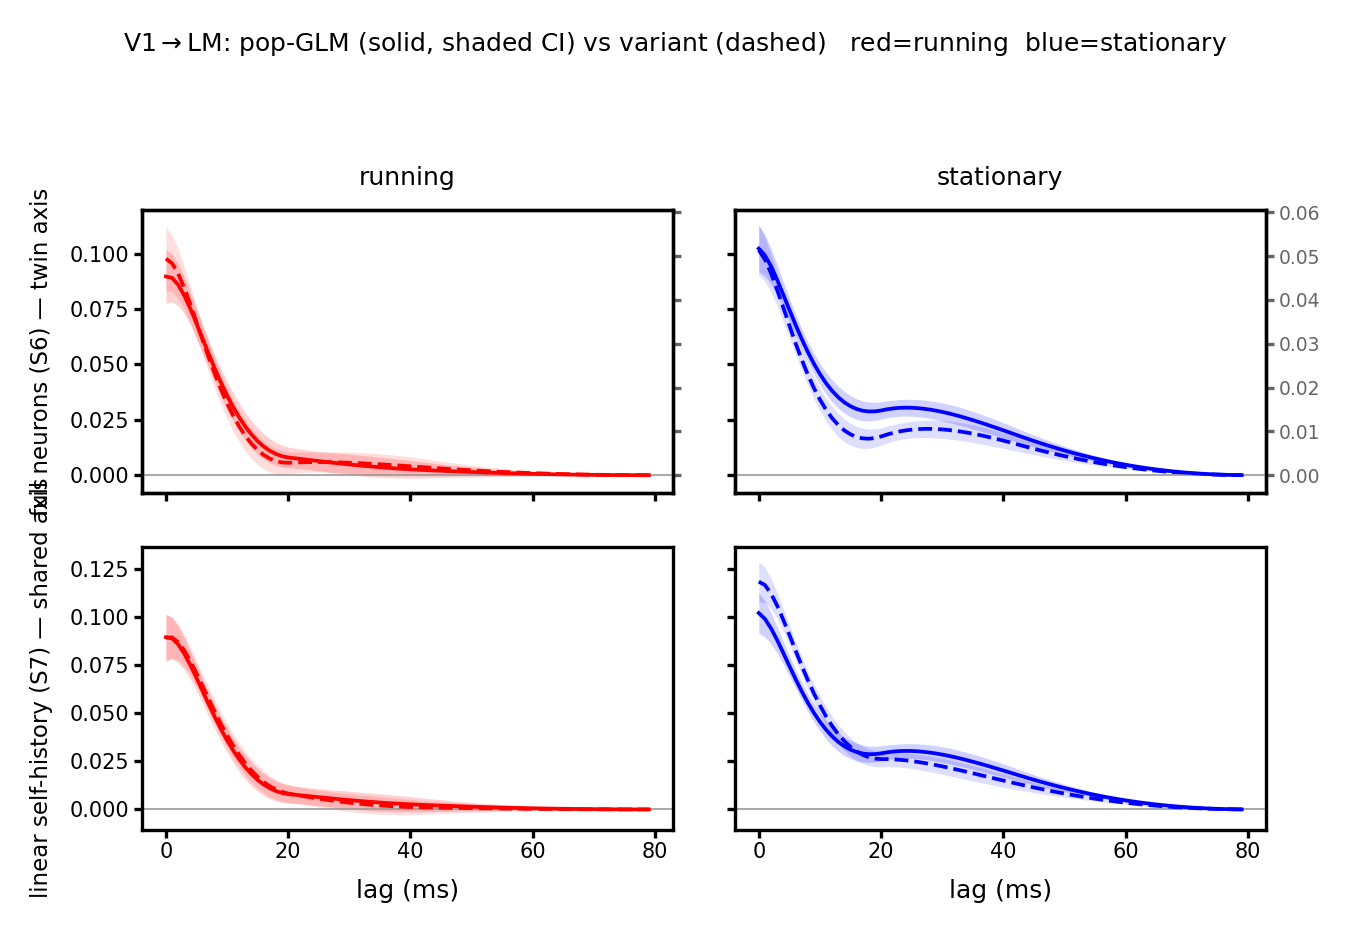

In [ ]:
Rci = pickle.load(open('exp2c_variants_ci.pkl','rb'))
from matplotlib.lines import Line2D
def fc(mo, co):
    d = Rci[(mo, co, 'probeD')]['probeC']; return np.asarray(d['f']), np.asarray(d['ci'])
def rng(mo):
    lo=hi=0
    for co in ['running','stationary']:
        f,ci = fc(mo,co); lo=min(lo,(f-2*ci).min()); hi=max(hi,(f+2*ci).max())
    return lo,hi
utils.use_pdf_plot()
fig, axes = plt.subplots(2, 2, figsize=(4.6, 3.0), dpi=300, sharex=True)
x = np.arange(len(fc('main','running')[0])); Lm = rng('main')
rows = [('fullpop','full neurons (twin axis)', True), ('linhist','linear self-hist (shared)', False)]
for r,(mo,lab,twin) in enumerate(rows):
    Rlo,Rhi = rng(mo)
    if twin: pad=0.06*(Lm[1]-Lm[0]); L=[Lm[0]-pad,Lm[1]+pad]; s=Rhi/Lm[1]
    else: lo=min(Lm[0],Rlo); hi=max(Lm[1],Rhi); pad=0.06*(hi-lo); L=[lo-pad,hi+pad]; s=1.0
    for cc,(co,c) in enumerate([('running','r'), ('stationary','b')]):
        a = axes[r,cc]; a.axhline(0, color='0.6', lw=0.4)
        fm,cim = fc('main',co); fv,civ = fc(mo,co)
        if twin:
            a2 = a.twinx(); a.set_zorder(a2.get_zorder()+1); a.patch.set_visible(False)
            a2.fill_between(x, fv-2*civ, fv+2*civ, color=c, alpha=0.13, lw=0); a2.plot(x, fv, color=c, lw=0.9, ls='--')
            a2.set_ylim([L[0]*s, L[1]*s]); a2.tick_params(colors='0.4', labelsize=4.5)
            if cc==0: a2.set_yticklabels([])
        a.fill_between(x, fm-2*cim, fm+2*cim, color=c, alpha=0.18, lw=0); a.plot(x, fm, color=c, lw=0.9, ls='-')
        if not twin:
            a.fill_between(x, fv-2*civ, fv+2*civ, color=c, alpha=0.13, lw=0); a.plot(x, fv, color=c, lw=0.9, ls='--')
        a.set_ylim(L); a.tick_params(labelsize=5)
        if cc==1: a.set_yticklabels([])
        if r==1: a.set_xlabel('lag (ms)')
        if r==0: a.set_title('running' if cc==0 else 'stationary', fontsize=6)
    axes[r,0].set_ylabel(lab, fontsize=5.5)
fig.suptitle(r'V1$\to$LM: pop-GLM (solid) vs variant (dashed); red=running, blue=stationary', fontsize=6, y=1.02)
plt.tight_layout()
from IPython.display import display; display(fig); plt.close(fig)

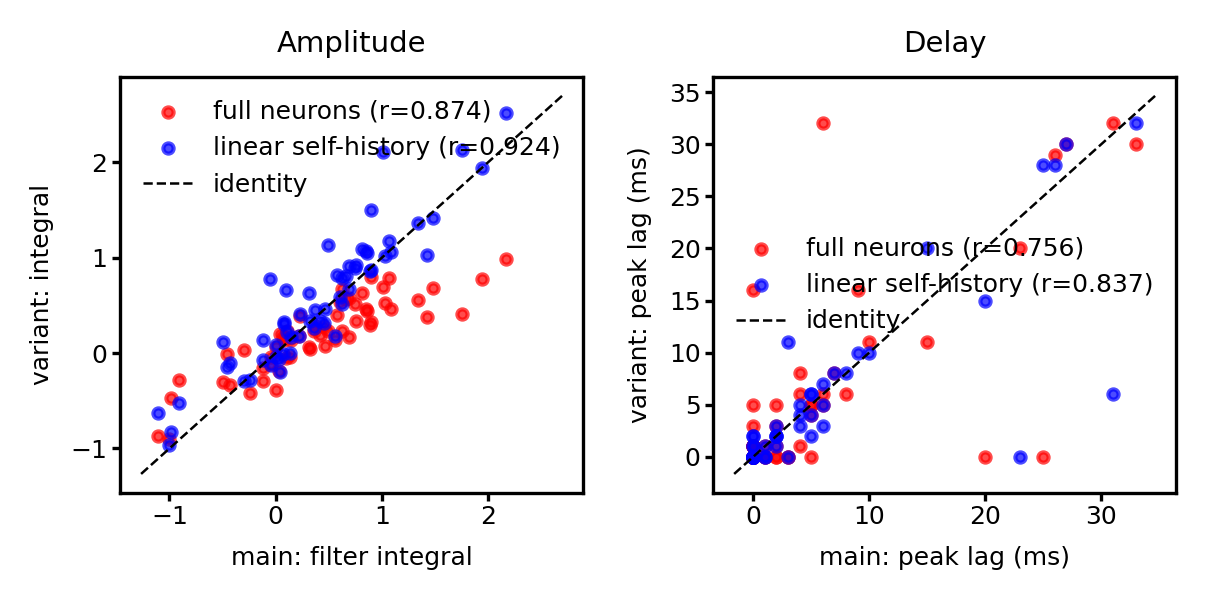

In [ ]:
# amplitude & delay correlation across all 60 cross-area filters
utils.use_pdf_plot()
fig, ax = plt.subplots(1, 2, figsize=(4.2, 2.1), dpi=300)
for (Av,Dv,c,lab) in [(Af,Df,'r','full neurons'), (Al,Dl,'b','linear self-history')]:
    ax[0].scatter(Am, Av, s=6, color=c, alpha=.7, label='%s (r=%.3f)' % (lab, np.corrcoef(Am,Av)[0,1]))
    ax[1].scatter(Dm, Dv, s=6, color=c, alpha=.7, label='%s (r=%.3f)' % (lab, np.corrcoef(Dm,Dv)[0,1]))
for a,(xl,yl,t) in zip(ax, [('main: filter integral','variant: integral','Amplitude'),
                            ('main: peak lag (ms)','variant: peak lag (ms)','Delay')]):
    lim=[min(a.get_xlim()[0],a.get_ylim()[0]), max(a.get_xlim()[1],a.get_ylim()[1])]
    a.plot(lim, lim, 'k--', lw=.6, label='identity')
    a.set_xlabel(xl); a.set_ylabel(yl); a.set_title(t); a.legend(frameon=False)
plt.tight_layout()
from IPython.display import display; display(fig); plt.close(fig)

**Conclusion.**

- **Linear self-history (S7):** filters are essentially unchanged (amplitude r = 0.92, scale 0.96×,
  delay r = 0.84; V1→LM 1.020/1.941 vs main 1.025/1.942). Dropping `f_damp` barely affects the coupling
  estimates — f_damp matters for *simulation stability*, not for the fitted coupling.
- **Full neurons (S6):** shape and timing are preserved (amplitude r = 0.87, delay r = 0.76) but the
  amplitude is roughly **halved** (scale 0.50×), the expected dilution by weakly tuned neurons.
- **All three models reproduce the key result:** V1→LM coupling is lower during running than stationary.

The full 6×6 filter grids (Figure-6 layout, variant on the left axis and main on the right) are in
`FigS_exp2c_fullpop_grid.pdf` and `FigS_exp2c_linhist_grid.pdf`.